## Setup and Imports

In [19]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## The Abstract Problem Interface

In [20]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

## The Node Class


In [21]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


## Helper Functions

In [22]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

 ## Implementing the Grid Search Problem

In [23]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []

        row, col = state
        for action in MOVES:
            dr, dc = MOVES[action]
            new_state = (row + dr, col + dc)

            if self.in_bounds(new_state) and self.is_free(new_state):
                legal_actions.append(action)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1



## Self-Check for GridProblem

In [24]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


## Sample Drone Map

In [25]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

## Visualisation Helper

In [26]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

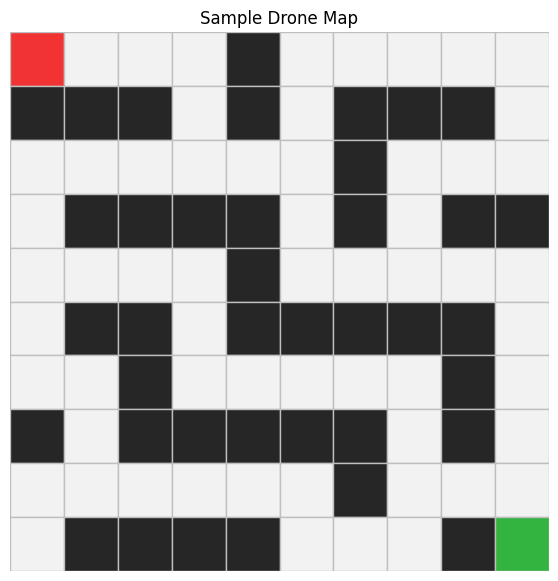

In [27]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

##  The Shared expand Method

In [28]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        state = node.state
        for action in problem.actions(state):
            next_state = problem.result(state, action)

            cost = node.path_cost + problem.action_cost(
                state,
                action,
                next_state
            )

            yield Node(
                state = next_state,
                parent = node,
                action = action,
                path_cost = cost
            )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

## Breadth-First Search (BFS)

In [29]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        node = Node(problem.initial_state())

        if problem.is_goal(node.state):

            return SearchResult(
                algorithm = algorithm,
                status = "success",
                solution = node,
                nodes_expanded = 0,
                max_frontier_size = 1,
                reached_count = 1
            )

        frontier = deque([node])
        reached = {node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):

                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm = algorithm,
                        status = "success",
                        solution=child,
                        nodes_expanded = nodes_expanded,
                        max_frontier_size = max_frontier_size,
                        reached_count= len(reached))

                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )




## Depth-First Search (DFS)

In [30]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        node = Node(problem.initial_state())

        if problem.is_goal(node.state):

            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1
            )

        frontier = [node]
        reached = {node.state}
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:

            node = frontier.pop()
            nodes_expanded += 1
            children = list(self.expand(problem,node))
            children.reverse()

            for child in children:
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )

                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

            max_frontier_size = max(
                max_frontier_size,
                len(frontier)
            )

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )



## Depth-Limited Search (DLS)

In [31]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }


        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        if problem.is_goal(node.state):
            return (node, "success")

        elif node.depth >= limit:
            return (None, "cutoff")

        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue

            metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)

            result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=current_stack_size + 1,
            )

            if status == "success":
                return (result, "success")
            elif status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return (None, "cutoff")
        else:
            return (None, "failure")


## Iterative Deepening Search (IDS)

In [32]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"
        dls = DepthLimitedSearch()

        iteration_log = []
        total_nodes = 0
        max_stack = 0

        for limit in range(max_depth+1):
            result = dls.search(problem,limit=limit)
            iteration_log.append({

                "limit":limit,

                "status":result.status
            })

            total_nodes += result.nodes_expanded

            max_stack = max(
                max_stack,
                result.max_frontier_size
            )

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes,
                    max_frontier_size=max_stack,
                    iterations=iteration_log,
                    reached_count=0
                )
            elif result.status == "failure":

                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes,
                    max_frontier_size=max_stack,
                    iterations=iteration_log,
                    reached_count=0
                )
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes,
            max_frontier_size=max_stack,
            iterations=iteration_log,
            reached_count=0
        )

 ## Run the Algorithms on the Sample Map

In [33]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,NaN,18.0,18.0,356,19,0


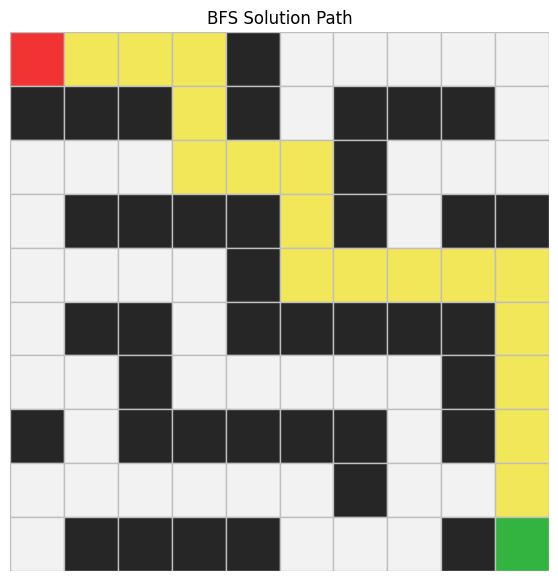

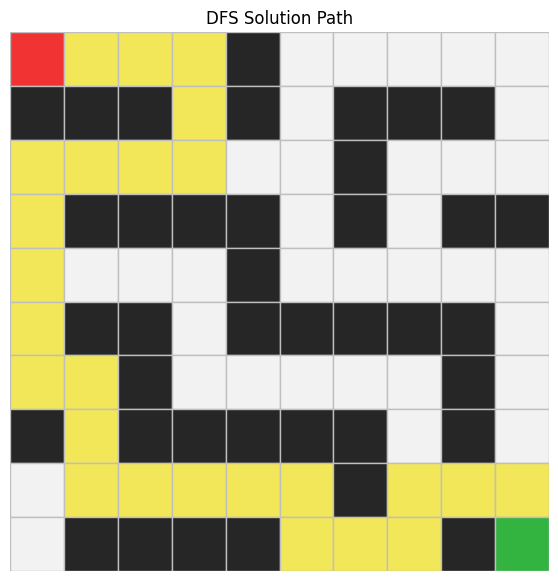

In [34]:
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

## Create Your Own Maps

In [35]:
custom_grid_1 = [
    [0,0,0,0,0,0,0],
    [1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1],
    [0,0,0,0,0,0,0],
    [1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0]
]

custom_start_1 = (0,0)
custom_goal_1 = (6,6)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,24.0,24.0,24,1,24
1,DFS,success,NaN,24.0,24.0,24,1,24
2,DLS,cutoff,20.0,NaN,NaN,20,21,0
3,IDS,success,NaN,24.0,24.0,300,25,0


In [36]:
custom_grid_2 = [
    [0,0,0,1,0,0,0],
    [1,1,0,1,0,1,0],
    [0,0,0,1,0,1,0],
    [0,1,1,1,0,1,0],
    [0,0,0,0,0,1,0],
    [1,1,1,1,0,1,0],
    [0,0,0,0,0,0,0]
]

custom_start_2 = (0,0)
custom_goal_2 = (6,6)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,16,16,20,3,22
1,DFS,success,NaN,24,24,24,2,25
2,DLS,success,20.0,16,16,27,21,0
3,IDS,success,NaN,16,16,143,17,0


## Reflection Questions

## 15.1 Problem Formulation

### What is a state in this lab?
A state is the current position of the drone on the grid, represented as a coordinate pair (row,column).


### What is an action?
an action is a legal movement the drone can make from its current state. the actions used in this lab are UP, DOWN, LEFT, RIGHT.


### What does the result function do?
The result function takes a current state and an action, then returns the new state reached after applying that action.


### Why is it useful to separate the problem definition from the search algorithm?
Seperating them makes the code flexible and reusable. The problem definition describes the environment, while the search algorithm only needs to know how to explore states. This allows the same BFS, DFS, DLS, or IDS algorithm to solve different problems without changing the algorithm itself.

## 15.2 BFS

### Why does BFS use a FIFO queue?
BFS uses a FIFO queue so  that nodes are explored in the order they were discovered. This makes sure that algorithm expands all states at one depth level before moving to thee next level.

### Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
Because BFS explores states level by level, the first time it reaches the goal is through the path with the fewest moves. On an unweighted grid, every move has the same cost, so the shallowest path is the shortest path.

### What role does the reached set play in BFS?
The reached set stores states that have already been visited. It prevents the algorithm from revisiting the same state repeatedly, which avoids infinite loops and reduces unnecessary work.

## 15.3 DFS

### Why does DFS use a stack?
DFS uses a stack because it explores one path as possible before backtracking. A LIFO structure supports this behaviour.
### Is DFS guaranteed to find the shortest path? Explain.
It is not because DFS may find a goal through a long path even when a shorter path exists elsewhere in the  search tree.
### Under what conditions can DFS use less memory than BFS?
DFS can use less memeory than BFS when the search tree is very wide but not very deep. BFS stores all frontier nodes at a depth level, while DFS mainly stores the current path and a few siblings.
### nder what conditions can DFS perform badly?
DFS can perform badly when the search space contains deep or infinite paths, many cycles, or when the goal is located near the top of the tree but DFS explores a deep wrong branch first.

## 15.4 DLS
### What happens when the depth limit is too small?
The algoritm may fail to reach the goal even if a solution exists deeper in the search tree.
### What is the meaning of "cutoff"?
"cuttoff" means the search stopped because it reached the depth limit before finding a solution.
### How is DLS different from ordinary DFS?
DLS is DFS with a maximum allowed depth. Ordinary DFS can continue indefinetly, while DLS stops expanding nodes once the depth limit is reached.
### Why do we use path-cycle checking in DLS?
Pathe-cycle checking prevents the search from revisiting states already on the current path. This avoids infinite loops caused by moving back and forth between the same states.

## 15.5 IDS

### Why does IDS repeat DLS with increasing limits?
IDS gradually increases the depth limit so it can first search shallow solutions and then deeper ones. This combines the low memory usage of DFS with the completeness of BFS.
### Why can IDS be complete even though DLS with a small limit is not?
A single DLS may miss the goal if the limit is too small, but IDS keeps increasing the limit until it is large enough to reach the goal, so it will eventually find a solution if one exists.
### Why does IDS use less memory than BFS?
IDS performs depth-first searches, so it only stores the current path and limited frontier information. BFS must store all nodes at the current depth level, which can be much larger.
### What is the cost of repeatedly searching from the root?
IDS repeats work because shallow nodes are expanded multiple times in different iterations. This increases the total time compared with BFS, although the memory usage remains low.

## 15.6 Real-World Drone Context
### In a real drone application, what might make one route safer or more practical than another?
A route could be safer if it avoids bad weather, obstacles, areas with poor GPS signals and strong winds, among others. A practical route may also maintain a stable flight altitude or minimize the drone's battery usage.
### Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
I would choose BFS because it has the same cost with every move and it guarantees finding the path with the fewest number of moves on the grid.  
### Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
I would choose DLS because it allows us to set a maximum search depth, which can represent a limit on how far the drone is allowed to explore from its starting position.
### What limitations does this grid model have compared with real drone navigation?
This grid model:
-Can only move in four directions
-Has an equal movement cost for every step
-Has  static obstacles
-Has no additional factors like altitude, speed etc